In [1]:
import numpy as np
import gc
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [2]:
expr_path = '/data/scRNA/ABCA/AIBS/AWS/expression_matrices/MERFISH-C57BL6J-638850/20230830/C57BL6J-638850-raw-wmeta-ccf.h5ad'
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 3739961 × 550
    obs: 'brain_section_label', 'cluster_alias', 'average_correlation_score', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'x_section', 'y_section', 'z_section', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'x_reconstructed', 'y_reconstructed', 'z_reconstructed', 'parcellation_index', 'x_ccf', 'y_ccf', 'z_ccf', 'parcellation_organ', 'parcellation_category', 'parcellation_division', 'parcellation_structure', 'parcellation_substructure', 'parcellation_organ_color', 'parcellation_category_color', 'parcellation_division_color', 'parcellation_structure_color', 'parcellation_substructure_color'
    var: 'gene_symbol', 'transcript_identifier'
    uns: 'accessed_on', 'src'

In [3]:
# Preprocess the data
sc.pp.normalize_total(adata, target_sum=1e4)  # Normalize counts per cell
sc.pp.log1p(adata)  # Log-transform the data

In [4]:
expr_path = '/data/scRNA/ABCA/AIBS/AWS/expression_matrices/MERFISH-C57BL6J-638850-imputed/20240831/C57BL6J-638850-imputed-log2-wmeta-ccf.h5ad'
adata_imp = sc.read_h5ad(expr_path)
adata_imp

AnnData object with n_obs × n_vars = 3739961 × 8460
    obs: 'brain_section_label', 'cluster_alias', 'average_correlation_score', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'x_section', 'y_section', 'z_section', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'x_reconstructed', 'y_reconstructed', 'z_reconstructed', 'parcellation_index', 'x_ccf', 'y_ccf', 'z_ccf', 'parcellation_organ', 'parcellation_category', 'parcellation_division', 'parcellation_structure', 'parcellation_substructure', 'parcellation_organ_color', 'parcellation_category_color', 'parcellation_division_color', 'parcellation_structure_color', 'parcellation_substructure_color'
    var: 'gene_symbol'

## DEGs

In [5]:
# Save the dataframe to a CSV file
# Selecting the brain region
select_region = "Isocortex-1"
group_by="class"
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
output_path = base_path / "outputs/DEG/" / f"WMB-10Xv3-{select_region}-DEG-{group_by}.csv"
deg_results = pd.read_csv(output_path)
deg_results.head()

,01 IT-ET Glut,02 NP-CT-L6b Glut,05 OB-IMN GABA,06 CTX-CGE GABA,07 CTX-MGE GABA,08 CNU-MGE GABA,30 Astro-Epen,31 OPC-Oligo,33 Vascular,34 Immune
0,C1ql3,Hs3st4,H3f3b,Adarb2,Kcnc2,Sox2ot,Plpp3,Olig1,Sparc,Laptm5
1,Cck,Cdh18,Zbtb20,Dlx6os1,Rab3b,Alk,Slc1a3,Qk,Utrn,Inpp5d
2,Tafa1,Foxp2,Msi2,Gad1,Slc32a1,Nkain3,Slc1a2,Gjc3,Zbtb20,Cst3
3,Bdnf,Nxph3,Sox4,Erbb4,Nxph1,Crhbp,Mt1,Sox10,Epas1,Serinc3
4,Nrgn,Rprm,Ttc28,Zfp536,Grip1,Npy,Gja1,Bcas1,Gng5,Csf1r


In [6]:
# Get the set of gene symbols in adata
adata_genes = set(adata.var['gene_symbol'])

# For each class (column) in deg_results, find overlap with adata gene panel for top 100 DEGs
overlap_dict = {}
for col in deg_results.columns:
    top_genes = deg_results[col].head(100)
    overlap = set(top_genes) & adata_genes
    overlap_dict[col] = overlap

# Print the number of overlapping genes for each class
for col, overlap in overlap_dict.items():
    print(f"{col}: {len(overlap)} genes overlap")
    print(sorted(overlap))

01 IT-ET Glut: 19 genes overlap
['C1ql3', 'Calb1', 'Car4', 'Ccn3', 'Chrm2', 'Cnr1', 'Kitl', 'Man1a', 'Megf11', 'Nptx2', 'Ntng1', 'Rmst', 'Rorb', 'Serpine2', 'Slit2', 'St6galnac5', 'Stxbp6', 'Synpr', 'Tafa1']
02 NP-CT-L6b Glut: 22 genes overlap
['Adamtsl1', 'Cdh9', 'Clic5', 'Col23a1', 'Cpa6', 'Grm3', 'Hs3st4', 'Ighm', 'Nrp1', 'Ntn1', 'Rab3b', 'Rprm', 'Rxfp1', 'Sema3e', 'Sema5a', 'Slc17a8', 'Spon1', 'Syt6', 'Tox', 'Tshz2', 'Vwc2l', 'Zfpm2']
05 OB-IMN GABA: 16 genes overlap
['Calb2', 'Fstl5', 'Gad2', 'Grik1', 'Igfbpl1', 'Kcnip1', 'Nxph1', 'Pax6', 'Pcp4l1', 'Ptprm', 'Slc1a3', 'Slc32a1', 'Sox2', 'Synpr', 'Syt6', 'Zic1']
06 CTX-CGE GABA: 36 genes overlap
['Adra1a', 'Adra1b', 'Cdh20', 'Cnr1', 'Cntn6', 'Crh', 'Cxcl14', 'Egfem1', 'Elfn1', 'Fstl5', 'Gad2', 'Galnt14', 'Grik1', 'Htr3a', 'Igf1', 'Kcnip1', 'Kcnmb2', 'Kit', 'Maf', 'Nr2f2', 'Parm1', 'Pcp4l1', 'Pde11a', 'Pnoc', 'Reln', 'Sema3c', 'Shisa6', 'Slc32a1', 'Sox2', 'Spock3', 'Synpr', 'Tent5a', 'Ust', 'Vip', 'Vwc2', 'Zfp536']
07 CTX-MGE GABA: 3

In [7]:
# Selecting the brain region
select_region = "Isocortex-1"
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"WMB-10Xv3-{select_region}-raw-wmeta.h5ad"
sc_adata = sc.read_h5ad(expr_path)

# Remove cells with less than 100 cells
class_counts = sc_adata.obs["class"].value_counts()
n_cells_threshold = 100
classes_to_remove = class_counts[class_counts < n_cells_threshold].index.tolist()
sc_adata = sc_adata[~sc_adata.obs["class"].isin(classes_to_remove)].copy()
sc_adata

AnnData object with n_obs × n_vars = 227325 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [8]:
# Preprocess the data
sc.pp.normalize_total(sc_adata, target_sum=1e4)  # Normalize counts per cell
sc.pp.log1p(sc_adata)  # Log-transform the data

In [9]:
def compute_tau_specificity(sc_adata, gene_list, groupby='class'):
    """
    Compute Tau specificity score for each gene in gene_list across groups in sc_adata.obs[groupby].
    Tau = sum(1 - (x_i / max(x))) / (n-1), where x_i is mean expression in group i.

    Returns:
        pandas.Series: Tau specificity values indexed by gene symbol.
    """
    gene_list = list(gene_list)
    gene_mask = sc_adata.var['gene_symbol'].isin(gene_list)
    genes_found = sc_adata.var['gene_symbol'][gene_mask]
    tau_scores = {}

    for gene in genes_found:
        gene_idx = np.where(sc_adata.var['gene_symbol'].values == gene)[0][0]
        expr = sc_adata.X[:, gene_idx].toarray().flatten() if hasattr(sc_adata.X, "toarray") else sc_adata.X[:, gene_idx]
        df = pd.DataFrame({'expr': expr, 'group': sc_adata.obs[groupby].values})
        group_means = df.groupby('group')['expr'].mean()
        x = group_means.values
        if np.max(x) == 0 or len(x) == 1:
            tau = np.nan
        else:
            tau = np.sum(1 - (x / np.max(x))) / (len(x) - 1)
        tau_scores[gene] = tau

    return pd.Series(tau_scores, name='tau_specificity')

In [10]:
# Example usage for class '34 Immune'
genes = overlap_dict['34 Immune']
tau_specificity = compute_tau_specificity(sc_adata, genes, groupby='class')
tau_specificity

/tmp/ipykernel_914677/934888528.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = df.groupby('group')['expr'].mean()


Ctss      0.996019
Maf       0.781424
Fli1      0.930429
Tgfbr2    0.910769
Fyb       0.995338
Name: tau_specificity, dtype: float32

In [11]:
# Example usage for class '34 Immune'
genes = overlap_dict['34 Immune']
tau_specificity = compute_tau_specificity(adata, genes, groupby='class')
tau_specificity

/tmp/ipykernel_914677/934888528.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = df.groupby('group')['expr'].mean()


Fli1      0.540668
Maf       0.835369
Ctss      0.806853
Fyb       0.911477
Tgfbr2    0.785107
Name: tau_specificity, dtype: float64

In [12]:
# Example usage for class '34 Immune'
genes = overlap_dict['34 Immune']
tau_specificity = compute_tau_specificity(adata_imp, genes, groupby='class')
tau_specificity

/tmp/ipykernel_914677/934888528.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = df.groupby('group')['expr'].mean()
/tmp/ipykernel_914677/934888528.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = df.groupby('group')['expr'].mean()
/tmp/ipykernel_914677/934888528.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = df.groupby('group')['expr'].mean()
/tmp/ipykernel_914677/

Maf       0.825597
Tgfbr2    0.892363
Fli1      0.967111
Ctss      0.992359
Fyb       0.984004
Name: tau_specificity, dtype: float32

## Plot cell labels

In [3]:
pred = (adata.obs['brain_section_label'] == 'C57BL6J-638850.38')
section = adata.obs[pred]
print("Number of cells in section:",len(section))

Number of cells in section: 120186


In [4]:
def plot_section(xx, yy, cc = None, val = None, fig_width = 8, fig_height = 8, cmap = None):
    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)
    if cmap is not None:
        plt.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
    elif cc is not None:
        plt.scatter(xx, yy, s=0.5, color=cc, marker='.')
    ax.set_ylim(11, 0)
    ax.set_xlim(0, 11)
    ax.axis('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    return fig, ax

In [5]:
def plot_section_with_legend(xx, yy, cc=None, val=None, fig_width=8, fig_height=8, cmap=None, legends=None):
    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)

    if val is not None and cmap is not None:
        sc = ax.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label("Value")

    elif legends is not None and cc is not None:
        # Ensure pandas Series, drop NaNs
        legends = pd.Series(legends)
        cc = pd.Series(cc)
        valid_mask = legends.notna() & cc.notna()

        xx = xx[valid_mask]
        yy = yy[valid_mask]
        legends = legends[valid_mask]
        cc = cc[valid_mask]

        unique_labels = legends.unique()

        for label in unique_labels:
            mask = legends == label
            color = cc[mask].iloc[0]  # assume consistent color per label
            ax.scatter(xx[mask], yy[mask], s=0.5, marker='.', color=color, label=label)
        ax.legend(markerscale=10, loc = "right", bbox_to_anchor=(1.27, 0.5), fontsize=6)

    elif cc is not None:
        ax.scatter(xx, yy, s=0.5, marker='.', color=cc)

    else:
        ax.scatter(xx, yy, s=0.5, marker='.', color='black')

    ax.set_ylim(11, 0)
    ax.set_xlim(0, 11)
    ax.axis('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    return fig, ax

In [75]:
def plot_gene_expression(adata, gene_symbol, cmap='viridis', fig_width=8, fig_height=8, title=None):
    """
    Plots the expression of a specified gene on the spatial coordinates.

    Args:
        adata: AnnData object containing the spatial transcriptomics data.
        gene_symbol: The gene symbol (string) to plot.
        cmap: Colormap to use for the expression values.
        fig_width: Width of the figure in inches.
        fig_height: Height of the figure in inches.

    Returns:
        The matplotlib figure and axes objects.
    """
    if gene_symbol not in adata.var['gene_symbol'].values:
        raise ValueError(f"Gene symbol '{gene_symbol}' not found in the AnnData object.")

    gene_index = np.where(adata.var['gene_symbol'] == gene_symbol)[0][0]
    gene_expression = adata.X[:, gene_index].toarray().flatten() # Get expression values as a 1D numpy array

    x_coords = adata.obs['x_reconstructed'].values
    y_coords = adata.obs['y_reconstructed'].values

    fig, ax = plot_section(x_coords, y_coords, val=gene_expression, cmap=cmap, fig_width=fig_width, fig_height=fig_height)
    if title is not None:
        ax.set_title(title)
    else:
        ax.set_title(f"Expression of {gene_symbol}")
    cbar = plt.colorbar(ax.collections[0], ax=ax) # Add a colorbar to show expression levels
    cbar.set_label("Expression Level")
    return fig, ax

In [7]:
division_mask = adata.obs['parcellation_division'] == 'Isocortex'
section_mask = adata.obs['brain_section_label'] == 'C57BL6J-638850.38'
pred_iso = division_mask & section_mask
isocortex_ad = adata[pred_iso]

In [ ]:
division_mask = adata_imp.obs['parcellation_division'] == 'Isocortex'
section_mask = adata_imp.obs['brain_section_label'] == 'C57BL6J-638850.38'
pred_iso = division_mask & section_mask
isocortex_ad_imp = adata_imp[pred_iso]

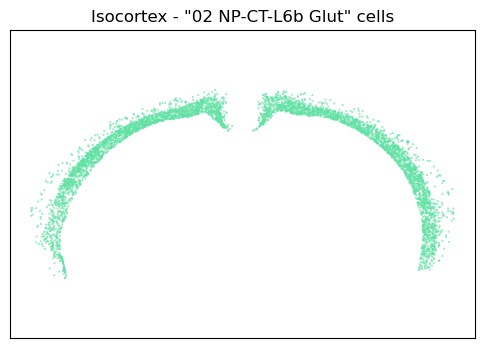

In [77]:
iso_class = isocortex_ad[isocortex_ad.obs['class'] == '02 NP-CT-L6b Glut']
fig, ax = plot_section(iso_class.obs['x_reconstructed'],
                       iso_class.obs['y_reconstructed'],
                       iso_class.obs['class_color'],
                       fig_width=6,
                       fig_height=4)
res = ax.set_title("Isocortex - \"02 NP-CT-L6b Glut\" cells")
plt.show()

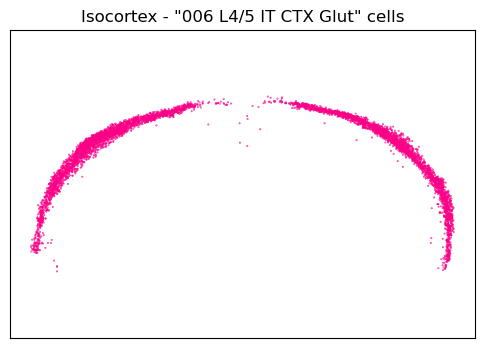

In [13]:
subclass_select = "006 L4/5 IT CTX Glut"
iso_class = isocortex_ad[isocortex_ad.obs['subclass'] == subclass_select]
fig, ax = plot_section(iso_class.obs['x_reconstructed'],
                       iso_class.obs['y_reconstructed'],
                       iso_class.obs['class_color'],
                       fig_width=6,
                       fig_height=4)
res = ax.set_title(f"Isocortex - \"{subclass_select}\" cells")
plt.show()

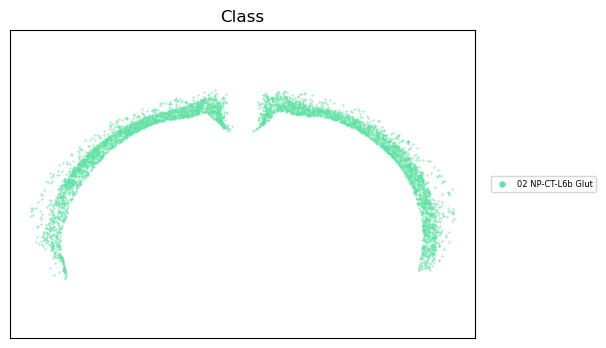

In [73]:
iso_class = isocortex_ad[isocortex_ad.obs['class'] == '02 NP-CT-L6b Glut']
fig, ax = plot_section_with_legend(iso_class.obs['x_reconstructed'],
                       iso_class.obs['y_reconstructed'],
                       iso_class.obs['class_color'],
                       legends=iso_class.obs['class'],
                       fig_width=6,
                       fig_height=4)
res = ax.set_title("Class")
plt.show()

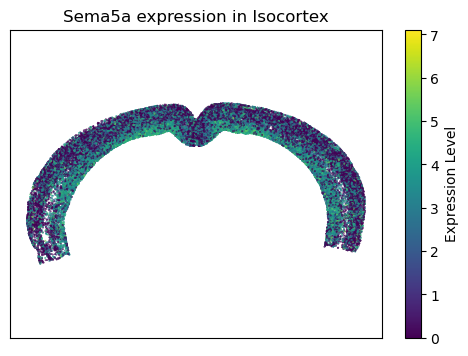

In [78]:
# Example usage:
gene_to_plot = list(overlap_dict['02 NP-CT-L6b Glut'])[0] # Replace with the gene you want to visualize
fig, ax = plot_gene_expression(isocortex_ad,
                               gene_to_plot,
                               fig_width=6,
                               fig_height=4,
                               title=f"{gene_to_plot} expression in Isocortex")
plt.show()

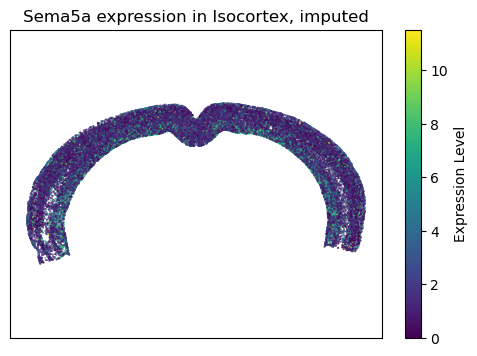

In [79]:
# Example usage:
gene_to_plot = list(overlap_dict['02 NP-CT-L6b Glut'])[0] # Replace with the gene you want to visualize
fig, ax = plot_gene_expression(isocortex_ad_imp,
                               gene_to_plot,
                               fig_width=6,
                               fig_height=4,
                               title=f"{gene_to_plot} expression in Isocortex, imputed")
plt.show()

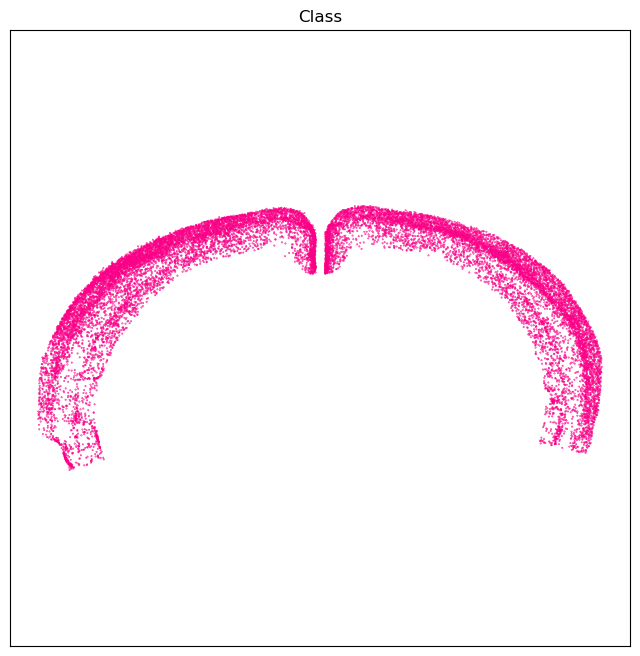

In [57]:
iso_class = isocortex_ad[isocortex_ad.obs['class'] == '01 IT-ET Glut']
fig, ax = plot_section(iso_class.obs['x_reconstructed'], iso_class.obs['y_reconstructed'], iso_class.obs['class_color'])
res = ax.set_title("Class")
plt.show()

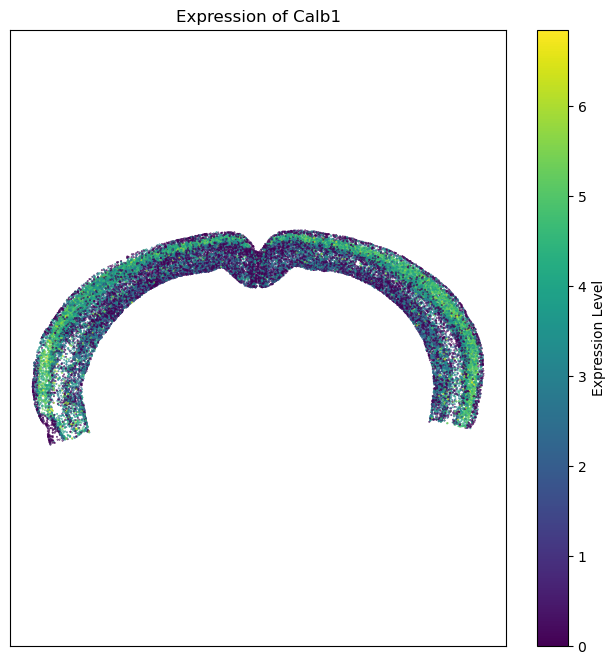

In [67]:
# Example usage:
gene_to_plot = list(overlap_dict['01 IT-ET Glut'])[5] # Replace with the gene you want to visualize
fig, ax = plot_gene_expression(isocortex_ad, gene_to_plot)
plt.show()

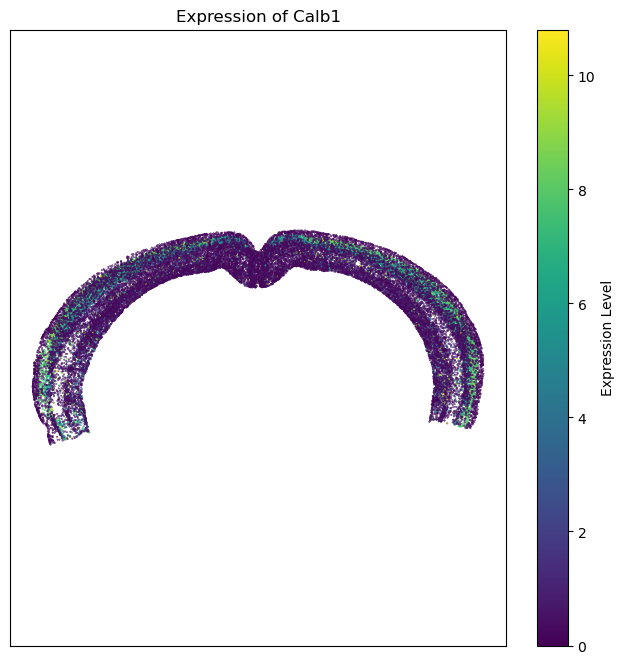

In [69]:
# Example usage:
gene_to_plot = list(overlap_dict['01 IT-ET Glut'])[5] # Replace with the gene you want to visualize
fig, ax = plot_gene_expression(isocortex_ad_imp, gene_to_plot)
plt.show()

In [45]:
isocortex_ad.obs['class'].value_counts()

class
01 IT-ET Glut        16366
02 NP-CT-L6b Glut     4977
30 Astro-Epen         4169
33 Vascular           4005
31 OPC-Oligo          2332
07 CTX-MGE GABA       1929
06 CTX-CGE GABA        977
34 Immune              620
08 CNU-MGE GABA         21
09 CNU-LGE GABA         15
13 CNU-HYa Glut         11
05 OB-IMN GABA           6
03 OB-CR Glut            5
11 CNU-HYa GABA          3
04 DG-IMN Glut           2
Name: count, dtype: int64